# Restricted Boltzmann Machines: Categorical Visible Units

Kai Zhang and Sora Sakai, Department of Chemistry and Biochemistry, The University of Texas at Tyler, 2025

__References__:

MNIST dataset

1. http://yann.lecun.com/

2. https://www.nist.gov/itl/products-and-services/emnist-dataset

CIFAR-10 dataset

3. https://www.cs.toronto.edu/~kriz/cifar.html

STL10 dataset
4. https://ai.stanford.edu/~acoates/stl10/


**Optimal or close-to-optimal training hyperparameters**:

| dataset (C) |split| n_hidden | n_epochs | lr (learning rate) |  CD or PCD| $k$ (MC steps)| update |generation| comments|
|:---------------:|:---------------:|:---------------:|:----------------:|:---------:|:------:| :-----: |:---:|:---:|:---:|
|MNIST (2)| training | 512      | 100    |  0.05       | CD |  10 | | $k>100$ some features, collapse to 9 | E_data: -2794.3265, E_model: -2729.1164, E_diff: 65.2102, CE: 0.1317|
|MNIST (2)| training | 512      | 100    |  0.05       | PCD |  10 | | $k>100$ some features,broken segments |E_data: -3102.1816, E_model: -2989.0104, E_diff: 113.1712, CE: 0.2049|
|MNIST (10)| training | 512      | 100    |  0.05       | CD |  10 | | $k>100$ some features, broken segments | E_data: -6760.8515, E_model: -6597.5751, E_diff: 163.2764, CE: 0.4380 |
|CIFAR10 (10)| training | 512      | 100    |  0.05       | CD |  10 | | $k>100$ some features | E_data: -3171.1660, E_model: -3059.7876, E_diff: 111.3784, CE: 0.9331|
|CIFAR10 (10)| training | 512      | 1000    |  0.001       | PCD |  10 | | $k>100$ some features, blocks | E_data: -3305.4674, E_model: -3261.0308, E_diff: 44.4366, CE: 1.0008|
|CIFAR10 (20)| training | 1024      | 1000    |  0.001       | PCD |  10 | | $k>100$ some features, blocks | E_data: -4251.2614, E_model: -4138.1662, E_diff: 113.0952, CE: 1.2570
|
|CIFAR10 (20)| training | 1024      | 1000    |  0.01       | PCD |  10 | | $k>100$ some features, blocks | E_data: -4037.6502, E_model: -3968.4180, E_diff: 69.2322, CE: 1.1450 |
|CIFAR10 (20)| training | 1024      | 1000    |  0.01       | CD |  10 | | $k>100$ some features, blocks | E_data: -4254.3747, E_model: -4199.1817, E_diff: 55.1930, CE: 1.0993|
 |q4-Potts (T=0.85)| training | 1024      | 1000    |  0.01       | PCD |  10 | | $k>100$ good |  E_data: -4884.1949, E_model: -4849.4315, E_diff: 34.7633, CE: 0.1677; fluctuating training metrics, especially at the beginning|
  |q4-Potts (T=0.85)| training | 1024      | 1000    |  0.05      | PCD |  10 | | $k>100$ partially collapse |  E_data: -3118.7197, E_model: -3122.0252, E_diff: -3.3055, CE: 0.3461 ; more fluctuating training metrics|
|q4-Potts (T=0.80)| training | 1024      | 1000    |  0.01     | PCD |  10 | | $k>100$ some bad samples with two peaks |  E_data: -3723.8532, E_model: -3710.8270, E_diff: 13.0262, CE: 0.2007|
|q4-Potts (T=0.80)| training | 1024      | 1000    |  0.01     | CD |  10 | | $k>100$ better |  E_data: -7678.6633, E_model: -7638.2703, E_diff: 40.3930, CE: 0.0205|
|q4-Potts (T=0.80)| training | 1024      | 2000    |  0.01     | CD |  10 | | $k>100$ some bad samples with two/three peaks | E_data: -10185.6914, E_model: -10159.3898, E_diff: 26.3016, CE: 0.0048 |
|q4-Potts (T=1.20)| training | 1024      | 1000    |  0.01     | CD |  10 | | $k>100$ domains size bigger than real | E_data: -9095.9580, E_model: -9083.8487, E_diff: 12.1094, CE: 0.0047 |
|q4-Potts (T=1.20)| training | 1024      | 1000    |  0.01     | PCD |  10 | | $k>100$ domains size looks better | more fluctuating, E_data: -12465.4864, E_model: -12323.6517, E_diff: 141.8347, CE: 0.0604 |



In [ ]:
import os
from os import path

import matplotlib.pyplot as plt
import numpy as np
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, random_split


In [ ]:
# Check PyTorch GPU availability and set device

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU device name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.9.0+cu128
CUDA available: True
CUDA device count: 1
GPU device name: NVIDIA GeForce RTX 4090


In [ ]:
C = 4  # number of classes of categorical integers
p = 32

In [ ]:
def discretize_and_onehot(x, bins=10):
    # x: grayscale image, shape e.g. [B, 32, 32] in [0,1]
    x = x.view(-1)  # flatten: [1024]
    x_bin = (x * bins).floor().clamp(max=bins - 1).long()  # [1024], ints 0,1,2,...
    x_onehot = F.one_hot(x_bin, num_classes=bins).float()  # [1024, 10]
    
    return x_onehot.view(-1)  # [nv*C]

In [ ]:
# Convert categorical integers to grayscale float image
# by mapping each category to the center of its bin.

def categories_to_image(x_cat, bins=10, image_size=(32, 32)):
    """
    x_cat: [1024] or [batch, 1024] integer categories (0..bins-1)
    Returns grayscale image(s) in [0,1], shape [1, H, W] or [B, 1, H, W]
    """
    x_float = (x_cat.float() + 0.5) / bins  # map bins -> midpoints in [0,1]
    x_float = x_float.view(-1, 1, *image_size)  # add channel dim
    return x_float

# 1. Datasets -- use one of the three example datasets

In [ ]:
# Define data directory path to where data is downloaded and/or stored.

data_dir = path.join("..", "data")

## 1.1 Load MNIST dataset from torchvision (comment out torch.round() to turn off binarization)

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html

In [ ]:
# Define data transformation: convert to tensor, discretize into C bins, and one-hot encode.
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.view(-1)),  # Flatten 28x28 -> 784
    transforms.Lambda(lambda x: discretize_and_onehot(x, bins=C)),
    # transforms.Lambda(lambda x: torch.round(x))  # binarize decimals to 0,1; comment out this line if continuous values needed
])

# Load MNIST training and test datasets
train_data = datasets.MNIST(root=data_dir, train=True, transform=transform, download=True)
test_data = datasets.MNIST(root=data_dir, train=False, transform=transform, download=True)
print(train_data.data.size(),train_data.targets.size())
print(test_data.data.size(),test_data.targets.size())

# Create data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=False)  # watch out PCD last batch size matching problem
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

torch.Size([60000, 28, 28]) torch.Size([60000])
torch.Size([10000, 28, 28]) torch.Size([10000])


In [ ]:
# Get a batch and inspect shapes

X_batch, y_batch = next(iter(test_loader))
print(X_batch.shape)
print(y_batch.shape)

torch.Size([64, 1568])


## 1.2 Load CIFAR10 dataset from torchvision

https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html

https://docs.pytorch.org/vision/0.9/datasets.html#cifar

In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x.view(-1)),  # Flatten 32x32 -> 1024
    transforms.Lambda(lambda x: discretize_and_onehot(x, bins=C)),
    # transforms.Lambda(lambda x: torch.round(x))
])

# 170M
cifar_train = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)
print("Train images:", len(cifar_train))
print("Test images:", len(cifar_test))

train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True)
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=True)

Train images: 50000
Test images: 10000


In [ ]:
# Get a batch and inspect shapes

X_batch, y_batch = next(iter(test_loader))
print(X_batch.shape)

torch.Size([64, 20480])


In [ ]:
# Convert one-hot vector back to categorical integers

X_batch_cat = X_batch.view(-1,p*p,C).argmax(dim=-1)
print(X_batch_cat.shape)

torch.Size([64, 1024])


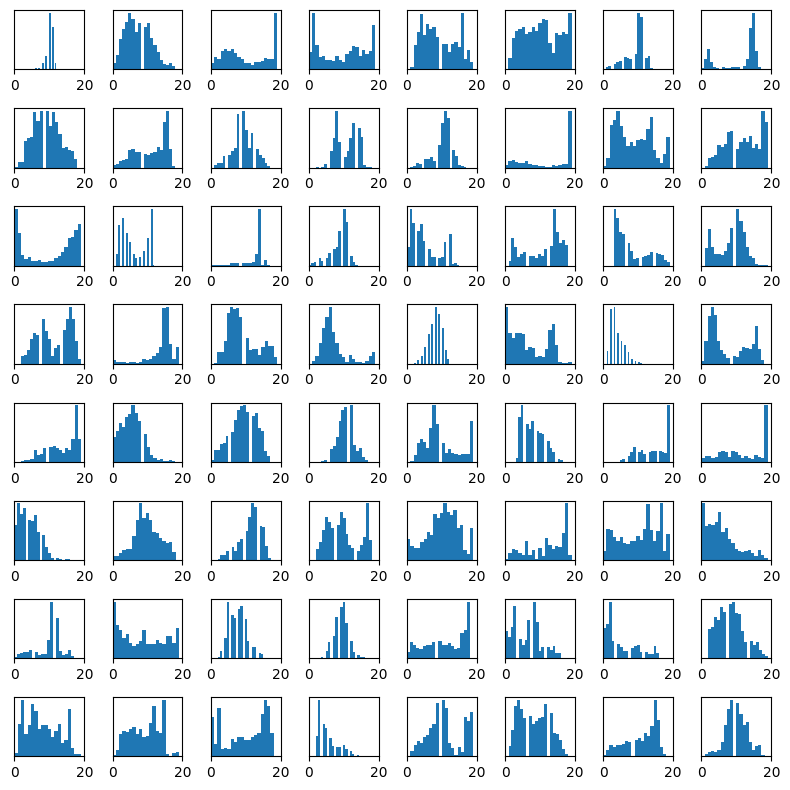

In [ ]:
# See pixel distributions

fig = plt.figure(figsize=(8, 8)) 
for i in range(64):  # 8 × 8 grid
    ax = fig.add_subplot(8, 8, i + 1)
    ax.hist(X_batch_cat[i].cpu().view(-1),bins=C) 
    ax.set_xlim(0,C)
    # ax.axis('off')
    # ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

torch.Size([64, 1, 32, 32])


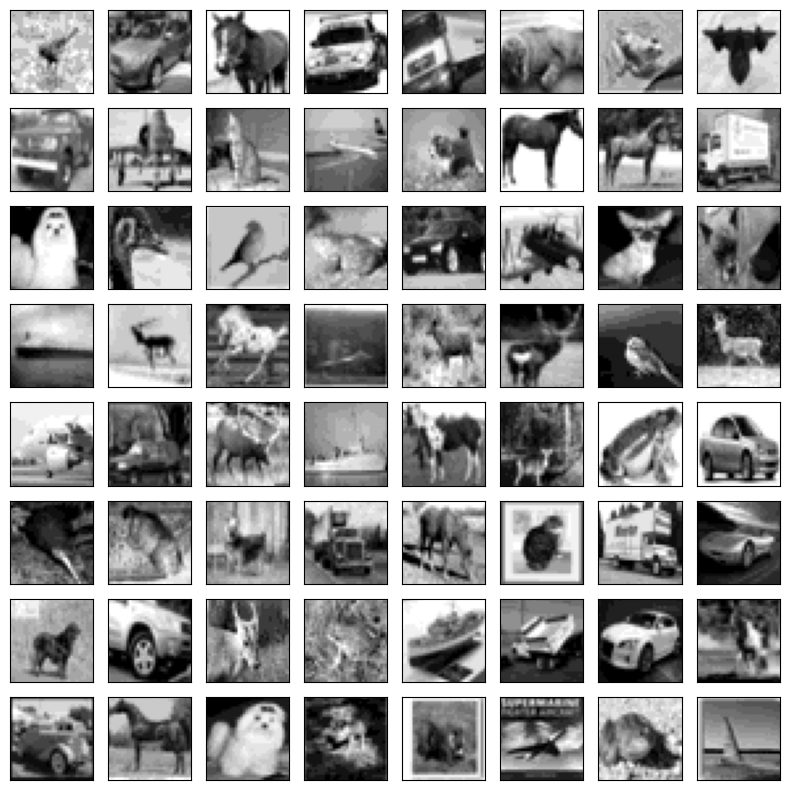

In [ ]:
# see sample images
img = categories_to_image(X_batch_cat, bins=C, image_size=(p,p))
print(img.shape)
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):  # 8 × 8 grid
    ax = fig.add_subplot(8, 8, i + 1)
    ax.imshow(img[i].cpu().view(32, 32), cmap="gray")
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.show()

## 1.3  Potts model configurations generated by Monte Carlo simulation
Download the potts model dataset from: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.19712829.svg)](https://doi.org/10.5281/zenodo.19712829), and put it inside data_dir.

---
Allowed Values:

<div style="display: flex; gap: 3rem;">

<div>

**q = 4**

| q | L | T |
|:----:|:----:|:----:|
|4| 32 | 0.600 |
|4| 32 | 0.650 |
|4| 32 | 0.700 |
|4| 32 | 0.750 |
|4| 32 | 0.800 |
|4| 32 | 0.850 |
|4| 32 | 0.900 |
|4| 32 | 0.950 |
|4| 32 | 1.000 |
|4| 32 | 1.050 |
|4| 32 | 1.100 |
|4| 32 | 1.150 |
|4| 32 | 1.200 |

</div>
<div>

**q = 10**

| q | L | T |
|:--:|:--:|:--:|
|10| 32 | 0.400 |
|10| 32 | 0.450 |
|10| 32 | 0.500 |
|10| 32 | 0.550 |
|10| 32 | 0.600 |
|10| 32 | 0.650 |
|10| 32 | 0.700 |
|10| 32 | 0.750 |
|10| 32 | 0.800 |
|10| 32 | 0.850 |
|10| 32 | 0.900 |
|10| 32 | 0.950 |
|10| 32 | 1.000 |

</div>
</div>

In [ ]:
q = 4
L = 32
T = 1.000

# Split ratio between train_data and test_data
split = 0.8

file_path = path.join(data_dir, f"2dPotts_L{L}", f"potts_configs_q{q}L{L}T{T:.3f}.npy")
configs = np.load(file_path)
print(configs.shape)

(20000, 1024)


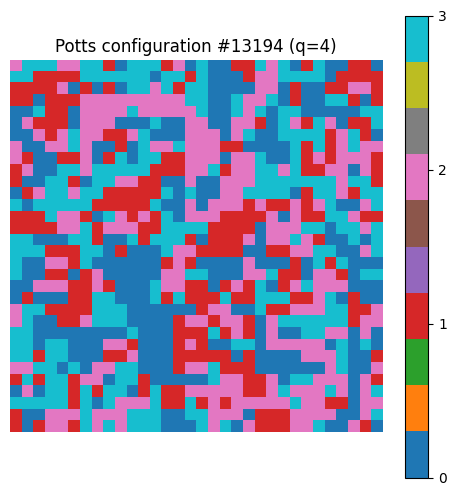

In [ ]:
index = np.random.randint(configs.shape[0])
config = configs[index]

import matplotlib.colors as mcolors
# Define discrete colors
colors = ['red', 'green', 'blue', 'orange']  # one color per spin
cmap = mcolors.ListedColormap(colors)
# Normalization: map integer values to colors
bounds = np.arange(q+1) - 0.5  # centers integers in color bins
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(6, 6))
plt.imshow(config.reshape(p,p), cmap="tab10", vmin=0, vmax=q-1)
# plt.imshow(config.reshape(p,p), cmap=cmap, norm=norm)
plt.title(f"Potts configuration #{index} (q={q})")
# plt.colorbar(label="Spin state")
plt.colorbar(ticks=np.arange(q))  # only integer ticks
plt.axis("off")
plt.show()

In [ ]:
class OneHotTransform:
    def __init__(self, q):
        self.q = q

    def __call__(self, x):
        # x is a 1D tensor of integers: shape (L*L,)
        # Output will be (L*L, q) or with transpose (q, L*L)
        return torch.nn.functional.one_hot(x.long(), num_classes=self.q).float()  #.transpose(0, 1)
        
class PottsDataset(Dataset):
    def __init__(self, npy_path='./', q=4, transform=None):
        self.data = np.load(npy_path)  # numpy array (n_samples, L*L)
        self.data = torch.from_numpy(self.data).long()  # convert to tensor (int64)

        filename = os.path.basename(npy_path)
        T = float(filename.split("T")[1].split(".npy")[0])
        self.T_label = torch.tensor(T).float()  # regression label

        self.phase_label = torch.tensor(0 if T < Tc else 1).long()  # Phase classification label

        self.q = q
        self.transform = transform

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]  # shape (L*L,)
        if self.transform:
            x = self.transform(x)
        return x, self.T_label  #, self.phase_label

In [ ]:
q = 4  # example Potts model q
Tc = 1.0 / np.log(1.0 + np.sqrt(q))
print('q =', q, 'and Tc =', Tc)

transform = transforms.Compose([
    OneHotTransform(q),
    transforms.Lambda(lambda x: x.view(-1)),  # Flatten  
])

dataset = PottsDataset(npy_path=file_path, q=q, transform=transform)

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
test_size  = dataset_size - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])  # split 80:20
print('train_size: ', train_size, 'test_size: ', test_size)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

X_batch, y_batch = next(iter(train_loader))
print(X_batch.shape)

q = 4 and Tc = 0.9102392266268373
train_size:  16000 test_size:  4000
torch.Size([64, 4096])


# 2. Define RBM with categorical units

In [ ]:
class RBM_multinomial(nn.Module):
    """
    RBM with categorical visible and binary hidden units
    parameters: W
    visible units v are represented by one-hot vectors
    learning with Markov Chain Monte Carlo methods
    CD-k or PCD-k 
    update parameters for one batch
    calculate data visible energy and model visible energy
    difference between data and model visible energies
    one-step reconstruction cross-entropy
    """
    def __init__(self, n_class, n_visible, n_hidden, mf=False):
        super(RBM_multinomial, self).__init__()
        self.n_visible = n_visible  # nv
        self.n_hidden = n_hidden  # nh
        self.n_class = n_class # C

        # Model parameters
        self.W = nn.Parameter(torch.randn(n_hidden, n_visible*n_class) * 0.01)  # (nh, nv*C)
        self.v_bias = nn.Parameter(torch.zeros(n_visible*n_class))  # (nv*C, )
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))  # (nh, )

        # Initialize persistent chain
        self.persistent_v = None
        self.mean_field = mf

    def xi(self, v):
        """
        v^T W^T + c
        input_shape: [batch_size, nv*C]
        output shape: [batch_size, nh]
        """
        return F.linear(v, self.W, self.h_bias)
    
    def omega(self, h):
        """
        h^TW + b
        input_shape: [batch_size, nh]
        output shape: [batch_size, nv*C]
        """
        return F.linear(h, self.W.t(), self.v_bias)
        
    def bernoulli_sampling(self, p):
        """Sampling from a Bernoulli distribution with prob p."""
        return torch.bernoulli(p)

    def v_to_h(self, v):
        """
        Compute p(h|v) = sigmoid(Wv + c)
        and sample v -> h
        input_shape: [batch_size, nv*C]
        output shape: [batch_size, nh]
        """
        p_h = torch.sigmoid(self.xi(v))
        return self.bernoulli_sampling(p_h)

    def h_to_v(self, h):
        """
        logits = h^TW + b # [batch_size, nv*C]
        probability p(v|h) = softmax(logits) -> # [batch_size*nv, C]
        multinomial distribution
        input_shape: [batch_size, nh]
        output shape: [batch_size, nv*C]
        """
        logits = self.omega(h)  # [batch_size, nv*C]
        # logits = logits.view(-1, self.n_visible, self.n_class)  # [batch_size, nv, C]
        logits = logits.view(-1, self.n_class)  # [batch_size*nv, C]
        p_v = F.softmax(logits, dim=-1)  # [batch_size*nv, C]
        # p_v_flat = p_v.view(-1, self.n_class)  # [batch_size*nv, C]
        samples = torch.multinomial(p_v, num_samples=1) # categorical {0,...,C-1}, [batch_size*nv, 1]
        v_sample = F.one_hot(samples.squeeze(1), num_classes=self.n_class)  # [batch_size*nv, C]
        v_sample = v_sample.view(-1, self.n_visible * self.n_class).float()  # [batch_size, nv*C]
        # p_v = p_v.view(-1, self.n_visible * self.n_class) # [batch_size, nv*C]
        return v_sample

    # def h_to_v_binary(self, h):
        # if self.mean_field == False: # binary v=0,1
        #    return self.bernoulli_sampling(p_v)
        # else:  # mean-field 0<v<1      
        #    return p_v

    def langevin_update(self, v, epsilon=0.1):
        """
        One Langevin step: v(t+1) = v(t) - epsilon^2/2 * dE/dv + epsilon*noise
        """
        v = v.view(-1, self.n_visible*self.n_class)  # [batch_size, nv]
       
        # if to use auto_diff
        # v = v.detach().clone().requires_grad_(True)
        # E = self.visible_energy(v).sum()
        # grad_v = torch.autograd.grad(E, v)[0] # dE/dv

        # if to calculate gradient dE/dv manually
        grad_v = -self.v_bias.t() - torch.sigmoid(self.xi(v)) @ self.W  # [batch_size, nv]
        
        # Gaussian noise
        noise = torch.randn_like(v)  # [batch_size, nv]

        # Langevin update
        v_new = v - (epsilon**2/2.) * grad_v + epsilon * noise

        # absorbing (0,1)
        return v_new.clamp(0,1)  #torch.sigmoid(v_new).detach()
        
    def forward(self, v, mc='gibbs', k=1, epsilon=0.1):
        """
        Performs k-step Gibbs sampling v->h->v' or
        k-step Langevin dynamics sampling v->v'
        """
        v = v.view(-1, self.n_visible*self.n_class)  # [batch_size, nv]
      
        if mc == 'gibbs':
            with torch.no_grad():  # Gibbs does not need to do auto_diff
                for _ in range(k):
                    h = self.v_to_h(v)
                    v = self.h_to_v(h)
                    
        elif mc == 'langevin':  # Langevin MUST keep autograd to use it
            for _ in range(k):
                v = self.langevin_update(v, epsilon)
            # v = self.bernoulli_sampling(v.detach())
                    
        return v  #.detach()   

    def visible_energy(self, v):
        """Compute the visible energy E(v)."""
        vbias_term = v.mv(self.v_bias)  # b^T v: [batch_size, nv*C] x [nv*C, 1] = [batch_size, 1]
        wxv_c = self.xi(v)  # Wv + c: [batch_size, nh]
        hidden_term = torch.sum(F.softplus(wxv_c), dim=1)  # [batch_size, 1]
        return -vbias_term - hidden_term

    def contrastive_divergence(self, v0, pcd=False, mc='gibbs', k=1, epsilon=0.1, lr=0.001):
        """
        Perform gradient descent for one batch
        with k-step Contrastive Divergence 
        """
        v_batch = v0.view(-1, self.n_visible*self.n_class)  # [batch_size, nv*C] 
        p_h_batch = torch.sigmoid(self.xi(v_batch))  # [batch_size, nh]

        # Initialize persistent chain the first time
        if self.persistent_v is None:
            self.persistent_v = v_batch.detach().clone()

        # data term
        self.W.grad = -torch.matmul(p_h_batch.t(), v_batch)/v_batch.size(0)  # [nh, nv]
        self.h_bias.grad = -torch.mean(p_h_batch, dim=0)  # [nh]
        self.v_bias.grad = -torch.mean(v_batch, dim=0)  # [nv]

        # Gibbs sampling
        if pcd == True: # PCD
            self.persistent_v = self.persistent_v.detach()
            v_sample = self.forward(self.persistent_v, mc, k, epsilon)  # [batch_size, nv]
            self.persistent_v = v_sample.detach().clone()           
        else: # CD
            v_sample = self.forward(v_batch, mc, k, epsilon)  # [batch_size, nv]
        
        p_h_sample= torch.sigmoid(self.xi(v_sample))  # [batch_size, nh]

        # data term - model term
        self.W.grad -= -torch.matmul(p_h_sample.t(), v_sample)/v_sample.size(0)  # [nh, nv]
        self.h_bias.grad -= -torch.mean(p_h_sample, dim=0)  # [nh]
        self.v_bias.grad -= -torch.mean(v_sample, dim=0)  # [nv]

        # Update parameters manually by gradient descent
        for param in [self.W, self.v_bias, self.h_bias]:
            param.data -= lr * param.grad
        
        # self.W.data.clamp_(-3, 5)
        
        E_data = torch.mean(self.visible_energy(v_batch))
        E_model = torch.mean(self.visible_energy(v_sample))       
        E_diff = E_model - E_data 
        # loss = nn.MSELoss(reduction='mean') 
        # MSE = loss(v_sample, v_batch) 
        
        # v_recon = self.forward(v_batch, mc='gibbs', k=1)
        # MSE = torch.mean((v_recon - v_batch)**2)

        logits = self.omega(self.v_to_h(v_batch))  # [batch_size, nv*C]
        CE = F.cross_entropy(logits.view(-1, self.n_class), v_batch.view(-1, self.n_class))  # [batch_size*nv, C] -> 1
        
        return E_data, E_model, E_diff, CE

In [ ]:
# define RBM model
C = q
p = 32
n_visible = p*p  # 28x28 or 32x32
n_hidden = 1024  # hidden units
mf = False  # mean-field v or not

cmap = 'tab10'
# cmap = 'gray'
# cmap = 'binary'

# if mf == True:
#    cmap = 'gray'
# elif mf == False:
#    cmap = 'binary'

rbm = RBM_multinomial(C, n_visible, n_hidden, mf).to(device)

# 3. Define and run the training loops

In [159]:
def train(model, train_loader, pcd, mc, k, epsilon, lr, n_epochs):
    if pcd == True:
        print(f"Training with PCD and {k}-step {mc} updates")
    else:
        print(f"Training with CD and {k}-step {mc} updates")
    
    history = {"E_data": [], "E_model": [], "E_diff": [], "CE": []}

    for epoch in range(n_epochs):
        E_data_epoch, E_model_epoch, E_diff_epoch, ce_epoch = 0., 0., 0., 0.
        for batch, (X_train, _) in enumerate(train_loader):
            X_train = X_train.to(device)
            E_data, E_model, E_diff, ce = model.contrastive_divergence(X_train, pcd, mc, k, epsilon, lr)
            E_data_epoch += E_data.item()
            E_model_epoch += E_model.item()
            E_diff_epoch += E_diff.item()
            ce_epoch += ce.item()
        
        E_data_epoch /= len(train_loader)
        E_model_epoch /= len(train_loader)
        E_diff_epoch /= len(train_loader)
        ce_epoch /= len(train_loader)
        
        history["E_data"].append(E_data_epoch)
        history["E_model"].append(E_model_epoch)

        history["E_diff"].append(E_diff_epoch)
        history["CE"].append(ce_epoch)
            
        print(f"Epoch {epoch + 1}/{n_epochs}, E_data: {E_data_epoch:.4f}, E_model: {E_model_epoch:.4f}, E_diff: {E_diff_epoch:.4f}, CE: {ce_epoch:.4f}")

    return history

In [ ]:
# define training hyperparameters

n_epochs = 1000
lr = 0.01
k = 10
pcd = True
mc = 'gibbs'  # gibbs or langevin
epsilon=0.05  # langevin step size

cdtype = 'pcd' if pcd else 'cd'

In [ ]:
# Run training. Replace train_loader with unlabeled_loader for STL10 if you want to train on unlabeled data.

history = train(rbm, train_loader, pcd, mc, k, epsilon, lr, n_epochs)

Training with PCD and 10-step gibbs updates
Epoch 1/1000, E_data: -832.2882, E_model: -588.9498, E_diff: 243.3384, CE: 0.9141
Epoch 2/1000, E_data: -1516.9343, E_model: -1233.0524, E_diff: 283.8819, CE: 0.5032
Epoch 3/1000, E_data: -1852.8637, E_model: -1580.1832, E_diff: 272.6805, CE: 0.3891
Epoch 4/1000, E_data: -2084.9603, E_model: -1818.3663, E_diff: 266.5940, CE: 0.3296
Epoch 5/1000, E_data: -2265.0990, E_model: -2011.6767, E_diff: 253.4223, CE: 0.2889
Epoch 6/1000, E_data: -2416.1329, E_model: -2164.6988, E_diff: 251.4341, CE: 0.2619
Epoch 7/1000, E_data: -2547.5627, E_model: -2308.7011, E_diff: 238.8616, CE: 0.2393
Epoch 8/1000, E_data: -2659.2923, E_model: -2422.8147, E_diff: 236.4777, CE: 0.2229
Epoch 9/1000, E_data: -2770.2358, E_model: -2535.6097, E_diff: 234.6261, CE: 0.2094
Epoch 10/1000, E_data: -2861.6351, E_model: -2634.9437, E_diff: 226.6914, CE: 0.1973
Epoch 11/1000, E_data: -2949.2153, E_model: -2723.4569, E_diff: 225.7584, CE: 0.1879
Epoch 12/1000, E_data: -3030.916

In [ ]:
# Specfiy output directory. Change Multinomial1 to desired directory name.

out_dir = path.join("..", "outputs", "Multinomial1")
os.makedirs(out_dir, exist_ok=True)

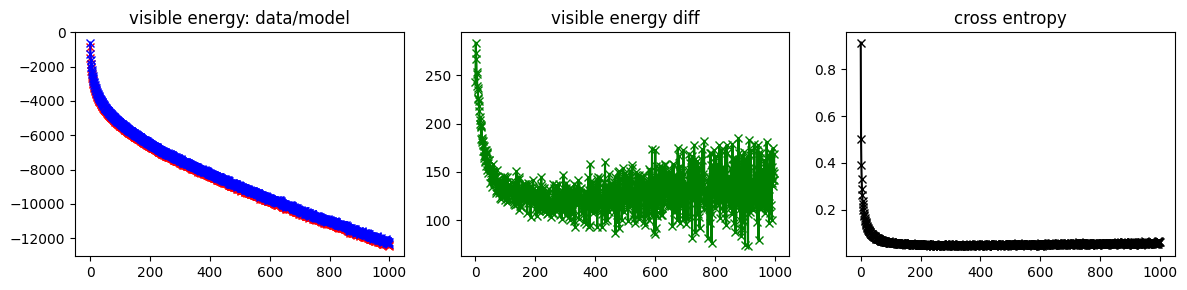

In [ ]:
# Plot history

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

axes[0].plot(history["E_data"],'rx-')
axes[0].plot(history["E_model"],'bx-')

axes[1].plot(history["E_diff"],'gx-')
axes[2].plot(history["CE"],'kx-')

axes[0].set_title('visible energy: data/model')
axes[1].set_title('visible energy diff')
axes[2].set_title('cross entropy')

plt.tight_layout()
plt.show()

#fig.savefig('./training_nh{}{}-{}{}_lr{}.png'.format(n_hidden,cdtype,k,mc,lr), dpi = 600, bbox_inches='tight')

# 4. Optional saving and reloading steps

## (4.1) Save model parameters and training results

In [ ]:
# Save parameters as numpy array files

for name, param in rbm.state_dict().items():
    print(f'parameter: {name}, size: {param.size()}')
    np.save(os.path.join(out_dir, f"{name}.npy"), param.cpu().numpy())

np.save(os.path.join(out_dir, f"training_nh{n_hidden}{cdtype}-{k}{mc}_lr{lr}.npy"), history, allow_pickle=True)  # save a list of dictionary

## (4.2) Reload parameters or training results

In [ ]:
################################################
# To load parameters from npy file
################################################

state_dict = rbm.state_dict()  # get a copy of current state dict
for name in state_dict.keys():
    param = np.load(os.path.join(out_dir, f"{name}.npy"))
    state_dict[name] = torch.tensor(param)

rbm.load_state_dict(state_dict)  # this actually loads the parameters

training_history = np.load(os.path.join(out_dir, f"training_nh{n_hidden}{cdtype}-{k}{mc}_lr{lr}.npy"), allow_pickle=True).tolist()  # a list of dictionary

# 5. Reconstruction test

In [ ]:
# Reconstruction

# Get batch
test_batch = next(iter(test_loader))
X_test = test_batch[0] if isinstance(test_batch, list) else test_batch

# Reconstruction from first 10 in batch
X_test = X_test[:10].to(device)
# X_test = X_test[:10].round().to(device)  # binary 0,1
X_recon = rbm.forward(X_test, mc='gibbs', k=1).detach() 
# X_recon = X_recon.clamp(0,1)

torch.Size([10, 1, 32, 32])


In [ ]:
# Convert one-hot back to categorical integers and then to images

img_test = categories_to_image(X_test.view(-1,n_visible,C).argmax(dim=-1), bins=C, image_size=(p, p))
img_recon = categories_to_image(X_recon.view(-1,n_visible,C).argmax(dim=-1), bins=C, image_size=(p, p))
print(img_test.shape)

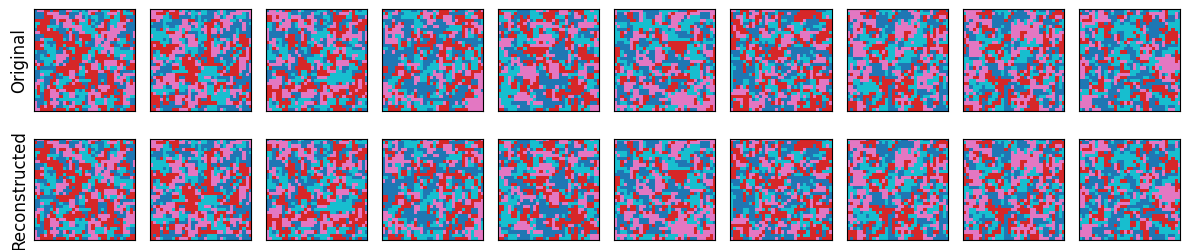

In [ ]:
# See Reconstructed vs Original images

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].imshow(img_test[i].cpu().view(p, p), cmap=cmap)  # use "binary" for v=0,1 "gray" for 0<v<1
    # axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    axes[1, i].imshow(img_recon[i].cpu().view(p, p), cmap=cmap)
    # axes[1, i].axis("off")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

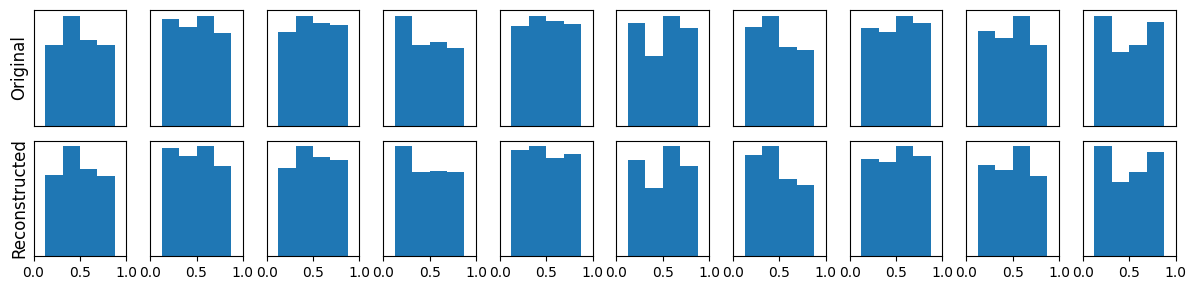

In [ ]:
# Check histogram distribution

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(img_test[i].cpu().view(-1),bins=C) 
    axes[0, i].set_xlim(0,1)
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(img_recon[i].cpu().view(-1),bins=C) 
    #axes[1, i].axis("off")
    #axes[1, i].set_xticks([])
    axes[1, i].set_xlim(0,1)
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

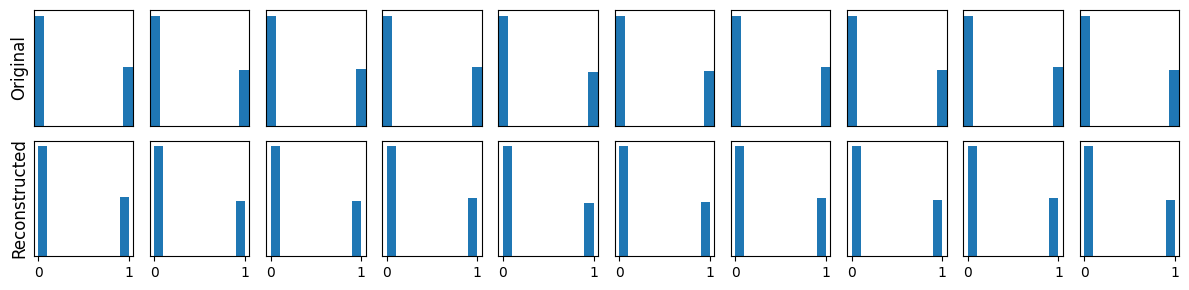

In [ ]:
# Check hidden units histogram

h_test = rbm.v_to_h(X_test.to(device)).detach() 
h_recon = rbm.v_to_h(X_recon.to(device)).detach()

fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(h_test[i].cpu().view(-1)) 
    axes[0, i].set_xlim(0,1)
    #axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(h_recon[i].cpu().view(-1)) 
    #axes[1, i].axis("off")
    #axes[1, i].set_xticks([])
    #axes[1, i].set_xlim(0,1)
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

# 6. Generation from random start

In [ ]:
# Generate starting from a random pixel distribution or a random hidden unit distribution.
# Commented out lines are for different initializations.

n_sample = 256

ph = 0.5  # Bernoulli probability
h0 = torch.bernoulli(torch.ones(n_sample, n_hidden)*ph).float().to(device)  # bernoulli 0,1 with probability ph
X0 = rbm.h_to_v(h0)

# X0 = torch.randint(1, (n_sample, n_visible),requires_grad=False).float().to(device)  # binary 0,1
# X0 = torch.rand((n_sample, n_visible),requires_grad=False).float().to(device)  # uniform [0,1]

torch.Size([256, 1, 32, 32])


In [ ]:
# Use Gibbs sampling for generation

with torch.no_grad():  # no graph, avoid GPU memory growth
    X_gen = rbm.forward(X0, mc='gibbs', k=1000, epsilon=0.01).detach()  # gibbs or manual diff langevin does not need graph

# X_gen = rbm.forward(X0, mc='langevin', k=1000, epsilon=epsilon).detach()  # langevin autodiff must use graph, GPU memory cautious
# X_gen = X_gen.clamp(0,1) 

In [ ]:
# Use Langevin dynamics for generation

X_gen = rbm.forward(X0, mc='langevin', k=1000, epsilon=epsilon).detach()  # langevin autodiff must use graph, GPU memory cautious
# X_gen = X_gen.clamp(0,1) 

In [ ]:
# Convert one-hot back to categorical integers and then to images

img_gen = categories_to_image(X_gen.view(-1,n_visible,C).argmax(dim=-1),bins=C, image_size=(p, p))
print(img_gen.shape)

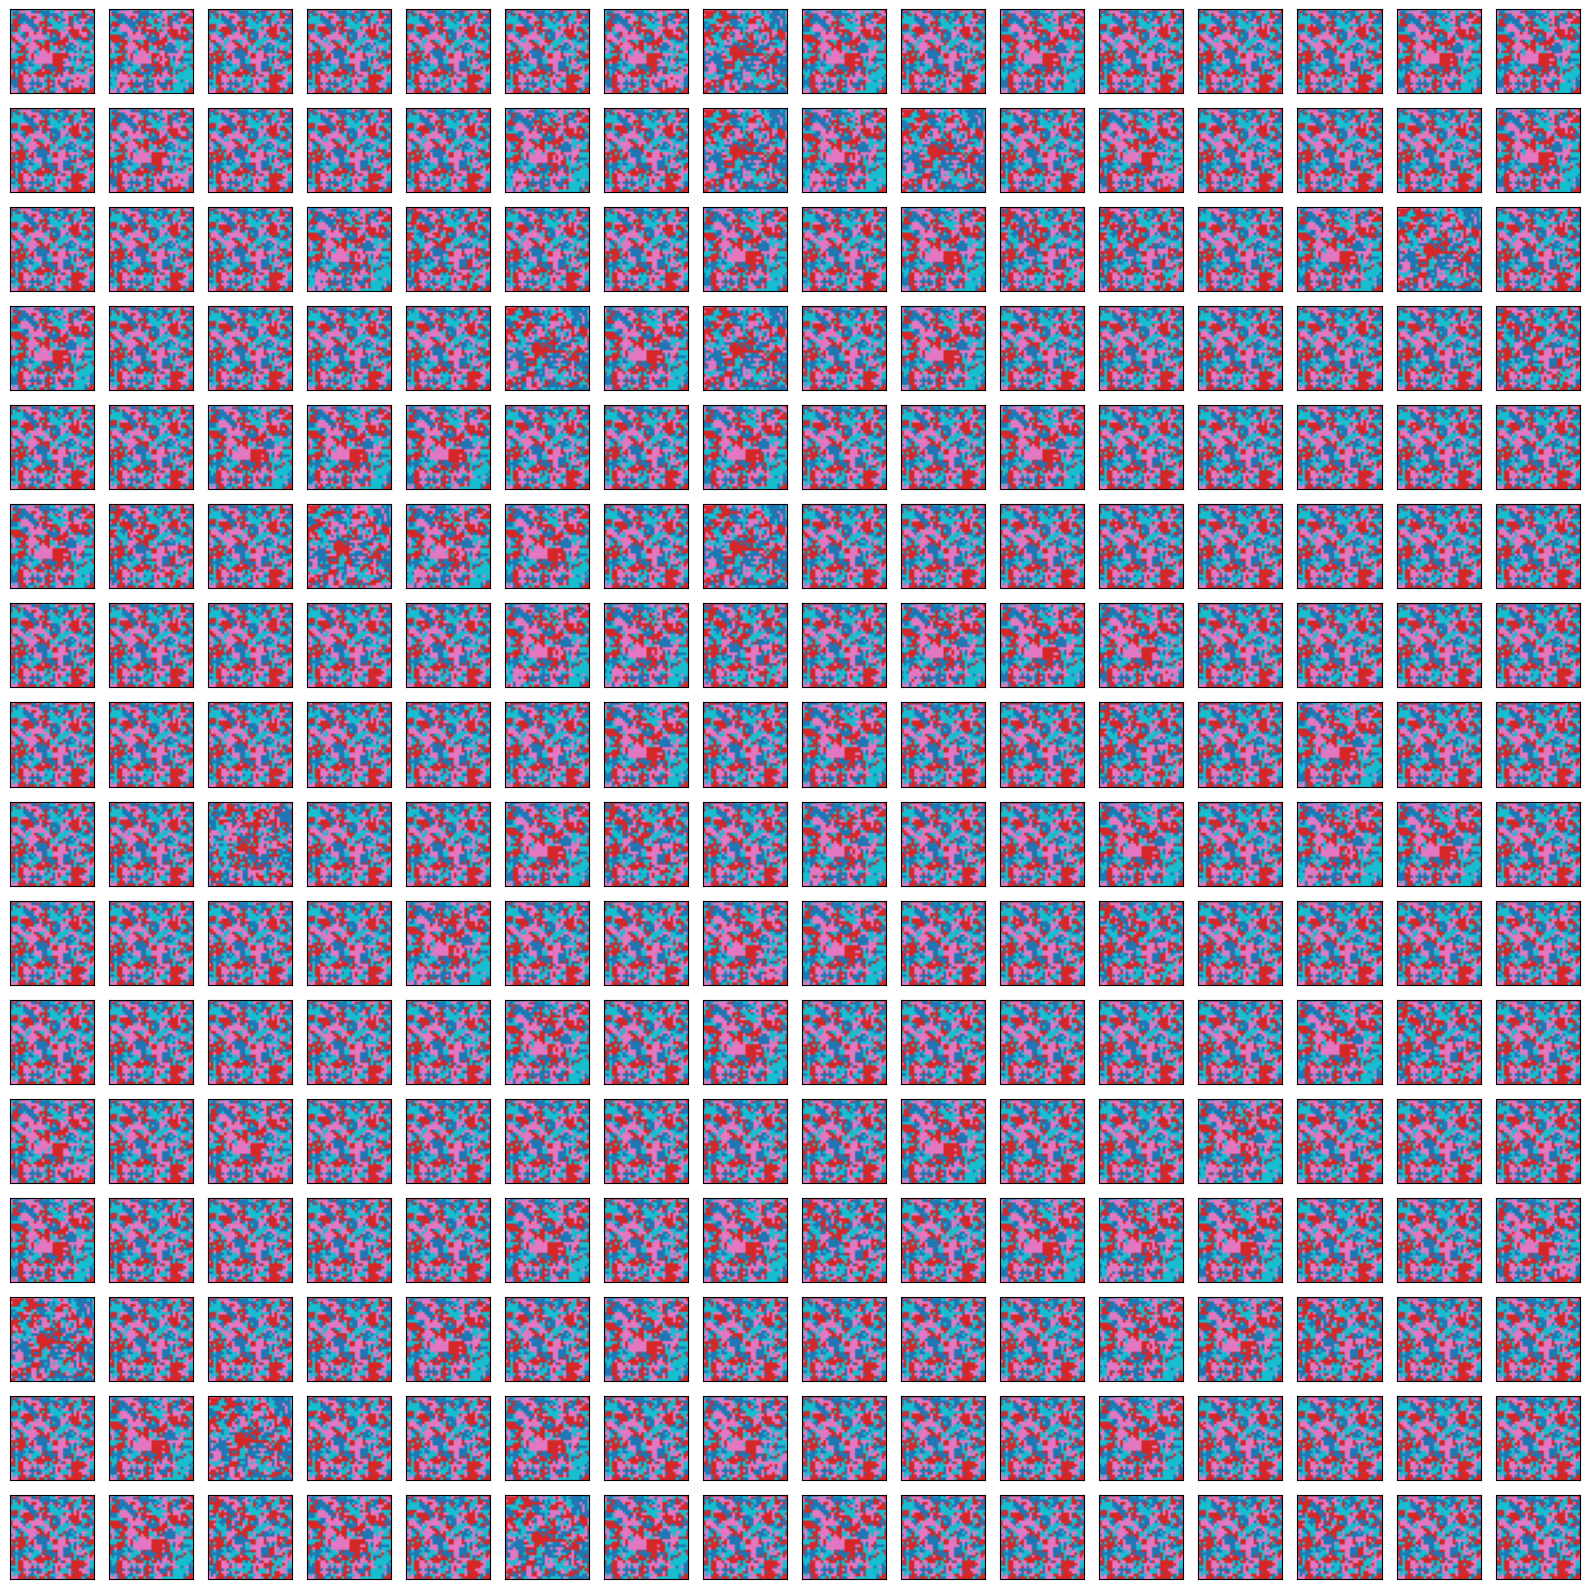

In [ ]:
# See generated images

fig = plt.figure(figsize=(16, 16)) 
for i in range(256):  # 16 × 16 grid
    ax = fig.add_subplot(16, 16, i + 1)
    ax.imshow(img_gen[i].cpu().view(p, p), cmap=cmap)
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

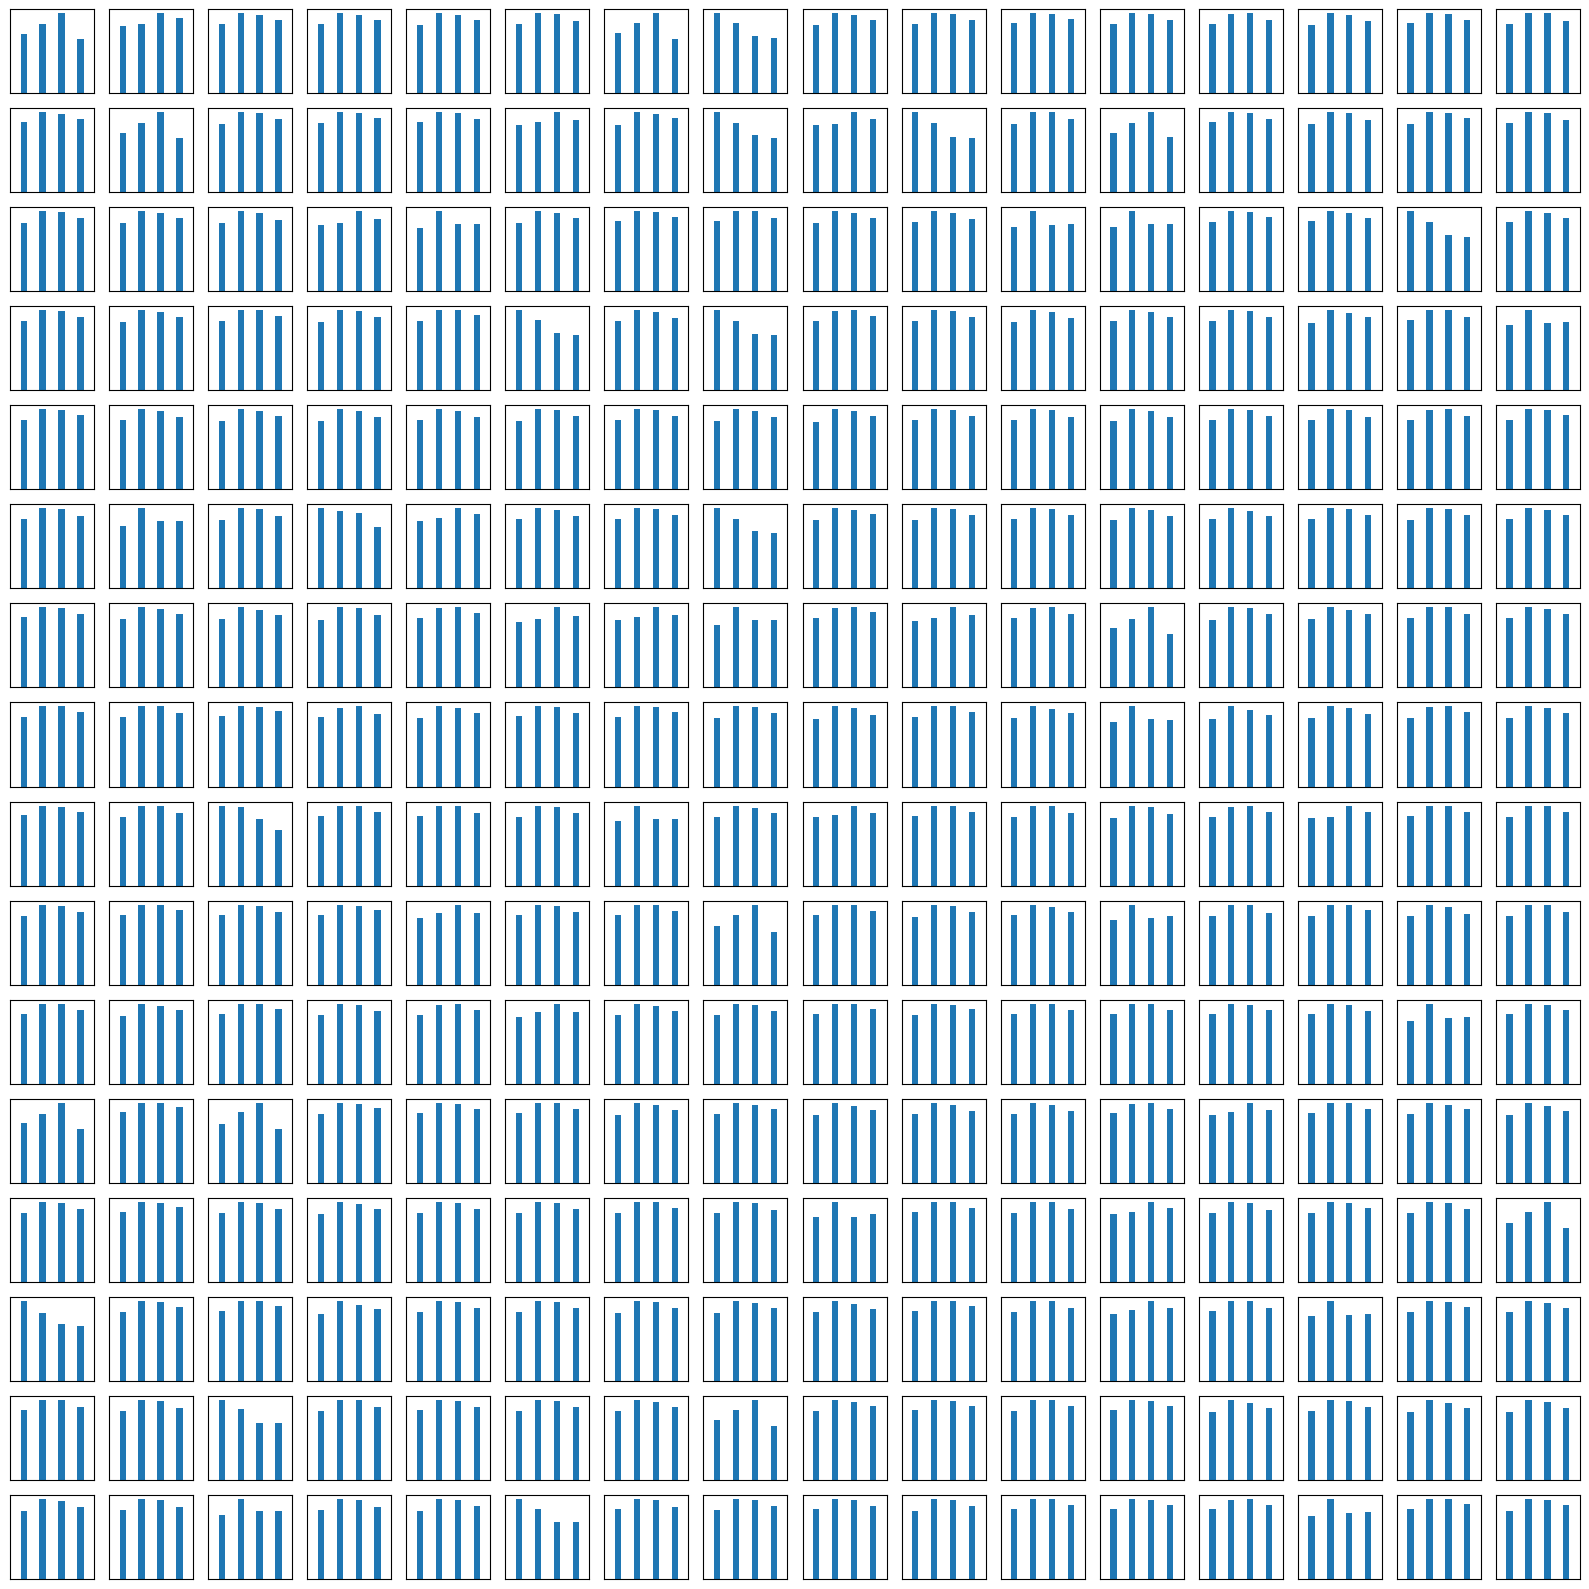

In [ ]:
# Check histogram distribution

fig = plt.figure(figsize=(16, 16)) 
for i in range(256):  # 16 × 16 grid
    ax = fig.add_subplot(16, 16, i + 1)
    ax.hist(img_gen[i].cpu().view(-1)) 
    # ax.axis('off')
    ax.set_xlim(0,1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

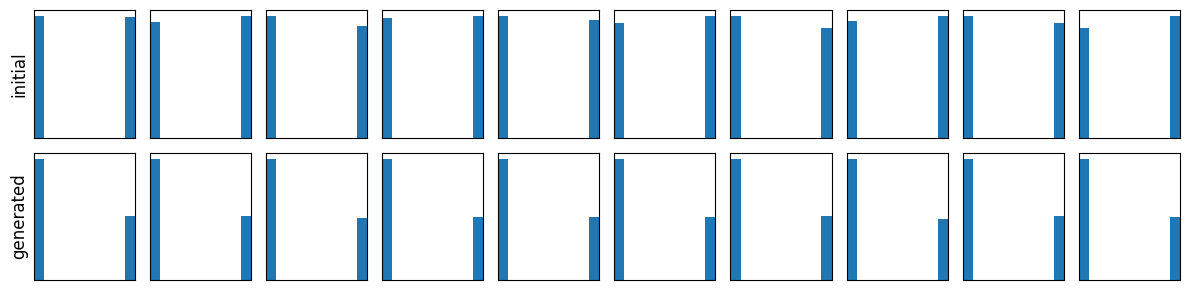

In [ ]:
# Get hidden units
with torch.no_grad():
    h0 = rbm.v_to_h(X0.to(device)).detach() 
    h_gen = rbm.v_to_h(X_gen.to(device)).detach() 

# Plot
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(10):
    axes[0, i].hist(h0[i].cpu().view(-1)) 
    axes[0, i].set_xlim(0,1)
    # axes[0, i].axis("off")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    axes[1, i].hist(h_gen[i].cpu().view(-1))
    axes[1, i].set_xlim(0,1)
    # axes[1, i].axis("off")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

axes[0, 0].set_ylabel("initial", fontsize=12)
axes[1, 0].set_ylabel("generated", fontsize=12)

plt.tight_layout()
plt.show()

## (optional) Check PCD persistent v batch


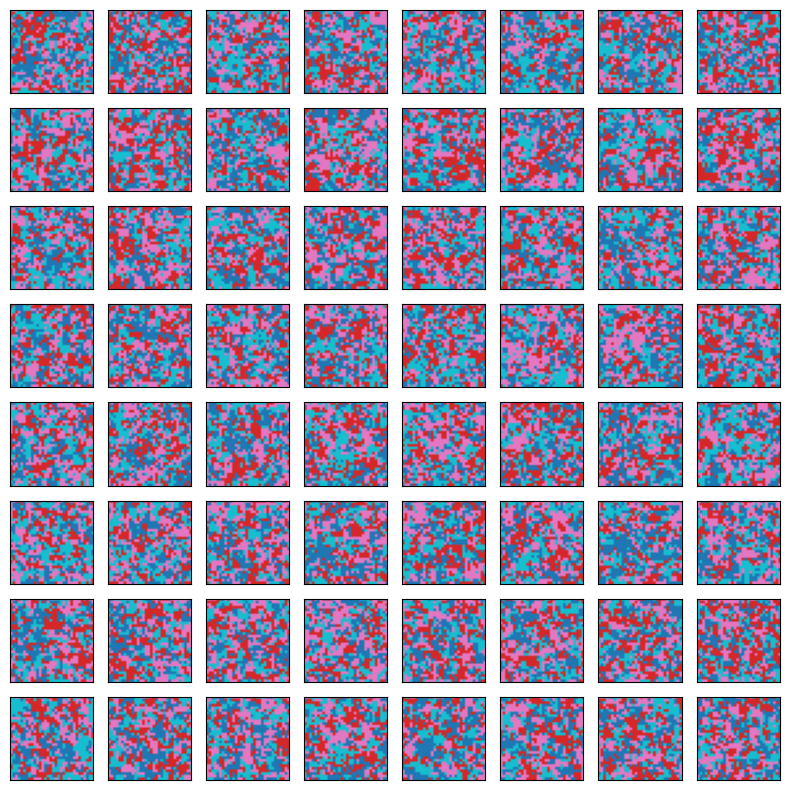

In [ ]:
# See images of the persistent batch

img_pcd_v = categories_to_image(rbm.persistent_v.view(-1,n_visible,C).argmax(dim=-1), bins=C, image_size=(p, p))
fig = plt.figure(figsize=(8, 8)) 
for i in range(64):  # 8 × 8 grid
    ax = fig.add_subplot(8, 8, i + 1)
    ax.imshow(img_pcd_v[i].cpu().view(p, p), cmap=cmap)
    # ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.tight_layout()
plt.show()

# 7. Plot weight matrix W as filters (row vectors folded)

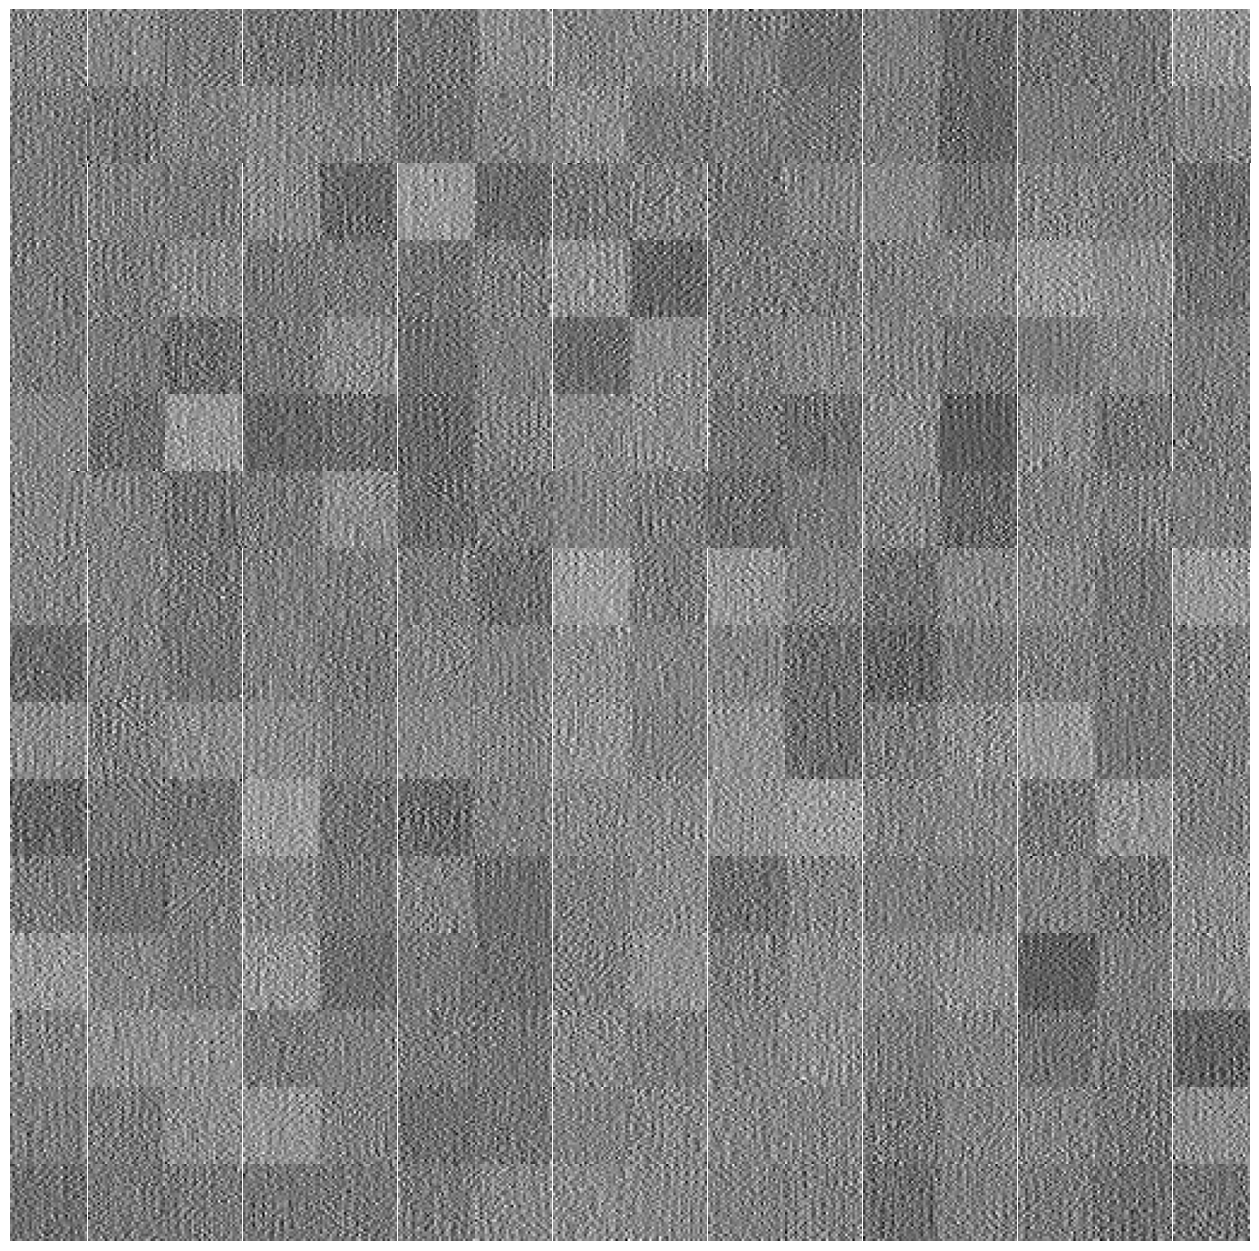

In [ ]:
c = 0  # 0,1,...,C-1
fig = plt.figure(figsize=(16, 16)) 
for i in range(256):  # 16 × 16 grid
    ax = fig.add_subplot(16, 16, i + 1)
    ax.imshow(rbm.W[i,c*n_visible:(c+1)*n_visible].detach().cpu().view(p, p), cmap="gray")
    ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.margins(0, 0)
# cbar = fig.colorbar(im, orientation='horizontal')  #, fraction=0.05, pad=0.02)
plt.show()

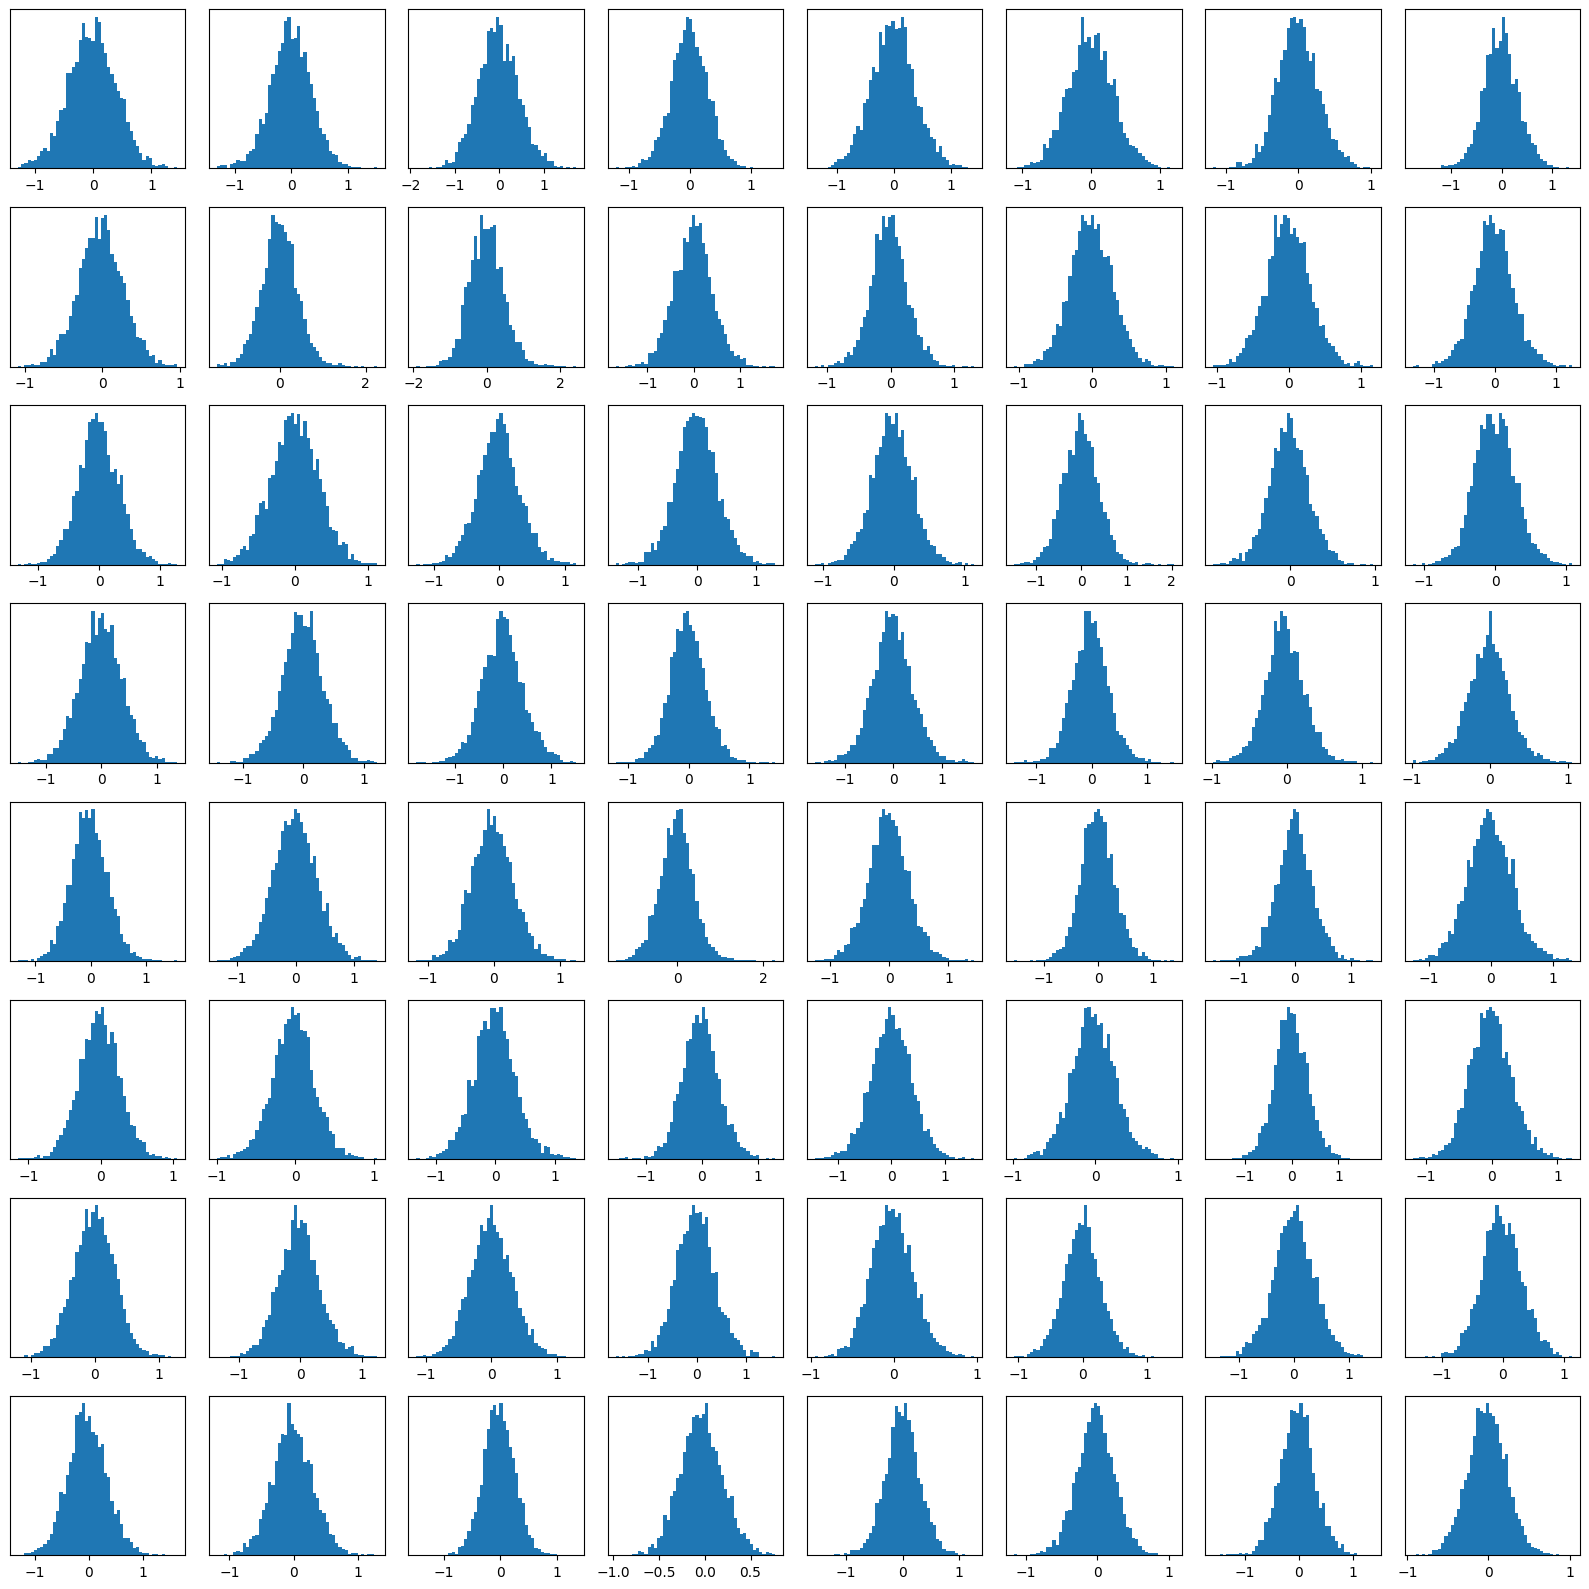

In [ ]:
# Plot histogram of weight matrix W filters

fig = plt.figure(figsize=(16, 16)) 
for i in range(64):  # 16 × 16 grid
    ax = fig.add_subplot(8, 8, i + 1)
    ax.hist(rbm.W[i].detach().cpu().view(-1), bins=50)
    # ax.axis('off')
    # ax.set_xlim(-4,4)
    # ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
# cbar = fig.colorbar(im, orientation='horizontal')  #, fraction=0.05, pad=0.02)
plt.show()

# The End